In [1]:
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3.6-27b") 

e:\Agents\agent\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# graph state
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

### Graph state
class State(TypedDict):
    topic:str
    characters:str
    settings:str
    premises:str
    story_intro:str

In [ ]:
##3 nodes
def generate_characters(state:State):
    """generate character description"""
    msg=model.invoke(f"create two character names and brief traits for a story about {state['topic']}")
    return {"characters":msg.content}

def generate_setting(state:State):
    """generate a story setting"""
    msg=model.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings":msg.content}

def generate_premises(state:State):
    """Generate a story premises"""
    msg=model.invoke(f"wrote a one-sentence plot premises for a story about {state['topic']}")
    return {"premises":msg.content}

def combine_elements(state:State):
    """Combine characters, setting, and premise into a intro"""
    msg=model.invoke(
        f"Write a short story intro using these elements: \n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premises: {state['premises']}"
    )
    return {"story_intro":msg.content}

In [19]:
#build the graph
graph=StateGraph(State)
graph.add_node("character",generate_characters)
graph.add_node("setting",generate_setting)
graph.add_node("premise",generate_premises)
graph.add_node("combine",combine_elements)

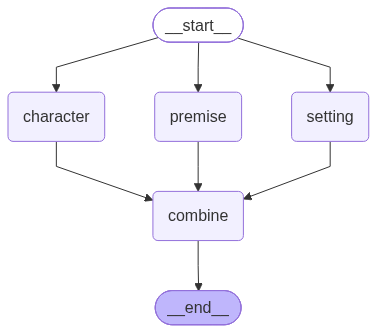

In [20]:
# Compile the graph
# define edges
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

# Compile the graph
compiled_graph = graph.compile()

# visualize
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [21]:
state={"topic":"time travel"}
result=compiled_graph.invoke(state)
print(result["story_intro"])


<think>
The user wants a setting for a time travel story.
I have already brainstormed and drafted a setting called "The Bazaar of Unspooled Hours" in the Rift of Aion.
The setting involves:
- A jagged tear in reality where time is non-linear.
- A bazaar/marketplace structure.
- Sensory details: Kaleidoscope sky, shifting architecture, polyphonic sounds, smells of ozone and old paper, temperature drifts.
- Mechanic: Anchors, dampeners, time-sickness.
- Narrative potential: Trading moments, instability, anchors failing.

I need to present this setting vividly. I should structure the output to be readable and inspiring for a writer.
Structure:
- Name and Location.
- Visuals (The Sky, The Architecture).
- Atmosphere (Sound, Smell, Touch).
- The "Rules" of the place (Anchors, Currency, Dangers).
- A "Writer's Hook" to tie it back to the characters or plot.

Let's refine the description for maximum vividness.
- *Sky:* "Kaleidoscope of eras." "Sun flickers between red giant and pale moon."
-

### Key Benfits
1.speed 
2.scalable 
3.modularity

### Takeaways
1.when to paralleize
2.langgrag support
3.merging